In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.model_selection as skm

from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)

from sklearn.metrics import (accuracy_score, log_loss)

from sklearn.ensemble import \
    (RandomForestRegressor as RF,
     RandomForestClassifier as RFC)

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from matplotlib.pyplot import subplots
from ISLP import load_data
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef,
                             classification_report, confusion_matrix)

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score


okabe_ito = {
    "orange":    "#E69F00",
    "sky_blue":  "#56B4E9",
    "green":     "#009E73",
    "yellow":    "#F0E442",
    "blue":      "#0072B2",
    "vermilion": "#D55E00",
    "pink":      "#CC79A7",
    "black":     "#000000",
}

oi_colors = list(okabe_ito.values())

In [8]:
Hitters = load_data("Hitters").dropna(subset=["Salary"])

X_df = Hitters.drop(columns = ["Salary"])

y_hitters = np.log(Hitters["Salary"].values)


X_train, X_test, y_train, y_test = skm.train_test_split(X_df,y_hitters,test_size = 0.3,random_state=0)


cat_cols = X_df.select_dtypes(include = ["object","category"]).columns.tolist()
num_cols = X_df.select_dtypes(include = ["number"]).columns.tolist()

ct = ColumnTransformer([
    ("cat",OneHotEncoder(drop="first",sparse_output = False),cat_cols),
    ("num","passthrough",num_cols)
])

X_train  = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

feature_names = ct.get_feature_names_out().tolist()







In [10]:
depths = range(1,25)

train_mse = []

test_mse = []


for d in depths:
    tree = DTR(max_depth = d,random_state =0 )
    tree.fit(X_train,y_train)


    train_mse.append(np.mean((y_train - tree.predict(X_train))**2))
    test_mse.append(np.mean((y_test - tree.predict(X_test))**2))

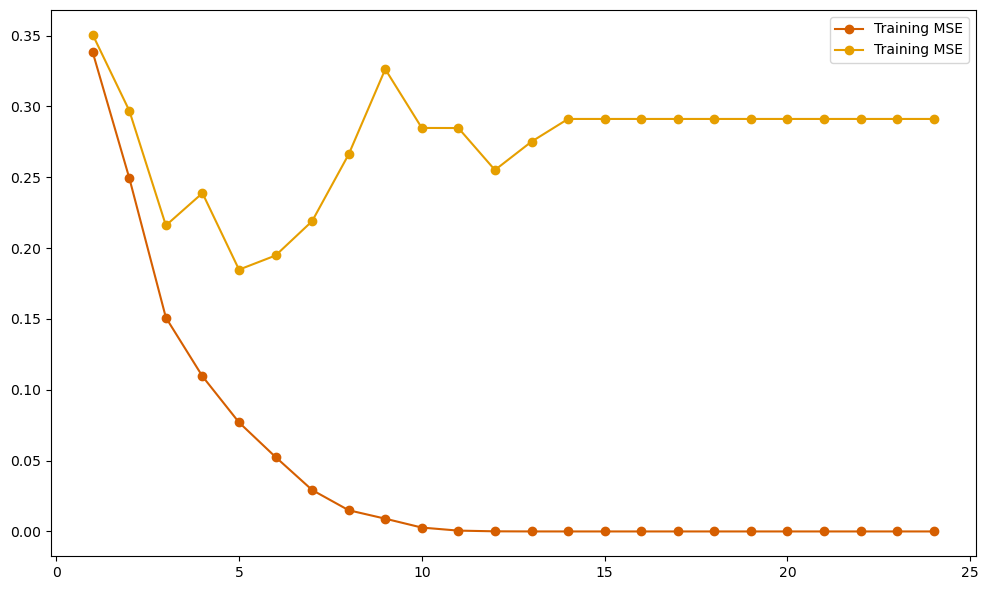

In [12]:
fig, ax = plt.subplots(figsize= (10,6))

ax.plot(depths,train_mse,"-o",color = okabe_ito["vermilion"],label="Training MSE")
ax.plot(depths,test_mse,"-o",color = okabe_ito["orange"],label="Training MSE")
ax.legend()
plt.tight_layout()


In [14]:
reg = DTR(random_state =0 )
reg.fit(X_train,y_train)


ccp_path = reg.cost_complexity_pruning_path(X_train,y_train)

alphas = ccp_path.ccp_alphas


kfold = skm.KFold(n_splits = 10, shuffle = True, random_state = 10)

grid = skm.GridSearchCV(
    DTR(random_state = 0),
    {"ccp_alpha": alphas},
    refit = True,
    cv = kfold,
    scoring = "neg_mean_squared_error"
)


G = grid.fit(X_train,y_train)

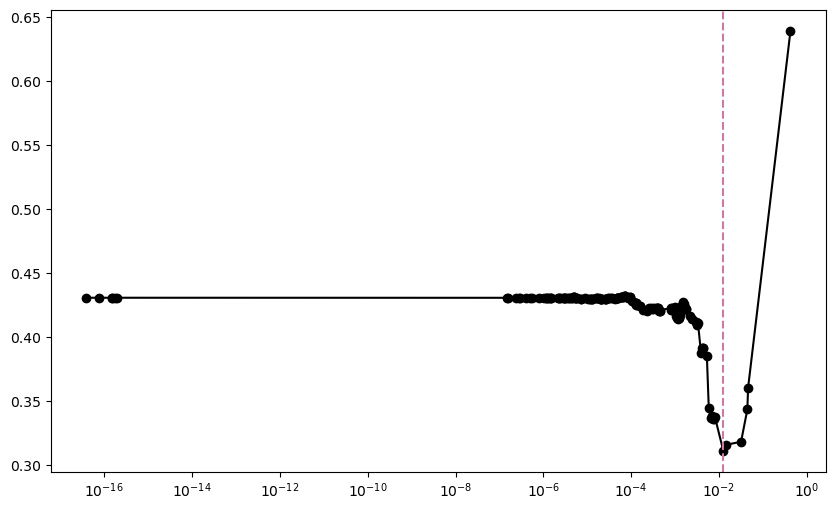

In [18]:
cv_mses = -G.cv_results_["mean_test_score"]

mask = alphas > 0 

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(alphas[mask],cv_mses[mask],"-o",color="k")
ax.axvline(G.best_params_["ccp_alpha"],color=okabe_ito["pink"],linestyle = "--")
ax.set_xscale("log")

In [29]:
bag_vec = np.unique(np.logspace(0,np.log10(5000),100).astype(int))

train_mse = []
test_mse = []


single_tree = G.best_estimator_

single_tree_mse = np.mean((y_test - single_tree.predict(X_test))**2)

for j, bag_n in enumerate(bag_vec):

    bag_hitters = RF(max_features = X_train.shape[1],n_estimators = bag_n, random_state = 0)
    bag_hitters.fit(X_train,y_train)

    y_hat_bag_train = bag_hitters.predict(X_train)
    train_mse.append(np.mean((y_train-y_hat_bag_train)**2))

    y_hat_bag_test = bag_hitters.predict(X_test)
    test_mse.append(np.mean((y_test-y_hat_bag_test)**2))


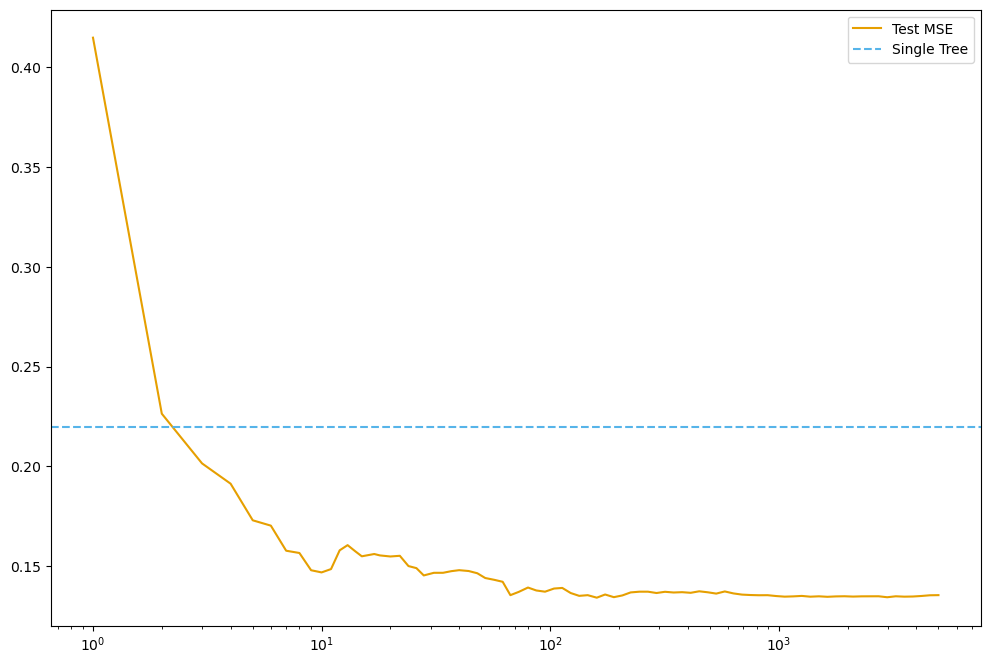

In [31]:
fig, ax = plt.subplots(figsize=(12,8))

ax.plot(bag_vec,test_mse,label = "Test MSE",color = oi_colors[0])
ax.axhline(single_tree_mse, linestyle = "--",color = oi_colors[1],label = "Single Tree")

ax.legend()
ax.set_xscale("log")

In [33]:
bag_n = 500

p = X_train.shape[1]

test_mses = []


for max_features in np.arange(1,p):
    rf = RF(max_features = max_features,n_estimators = bag_n, random_state = 1)
    rf.fit(X_train,y_train)
    test_mses.append(np.mean((y_test-rf.predict(X_test))**2))




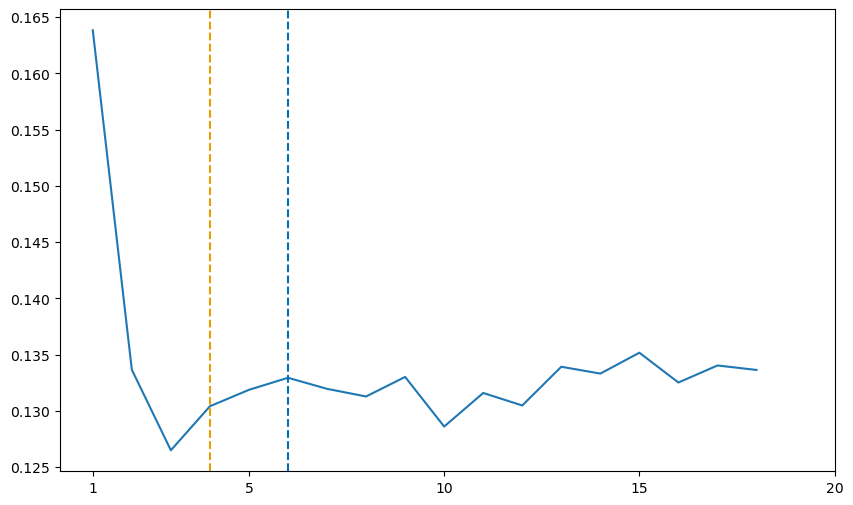

In [38]:
fig, ax = plt.subplots(figsize = (10,6))

ax.plot(np.arange(1,p),test_mses)
ax.set_xticks([1,5,10,15,20])

ax.axvline(int(np.sqrt(p)),color = okabe_ito["orange"],linestyle="--")
ax.axvline(int(p/3),color = okabe_ito["blue"],linestyle="--")


In [43]:
bag_vec = np.arange(1,1000,5)

rf_oob = []
rf_test = []

bag_oob = []
bag_test = []


for bag_n in bag_vec:

    rf = RF(max_features = 3, n_estimators = bag_n, oob_score = True, random_state =1)
    rf.fit(X_train,y_train)
    rf_oob.append(np.mean((y_train - rf.oob_prediction_)**2))
    rf_test.append(np.mean((y_test - rf.predict(X_test))**2))


    bag = RF(max_features = p, n_estimators = bag_n, oob_score = True, random_state =1)
    bag.fit(X_train,y_train)
    bag_oob.append(np.mean((y_train - bag.oob_prediction_)**2))
    bag_test.append(np.mean((y_test - bag.predict(X_test))**2))







/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/george

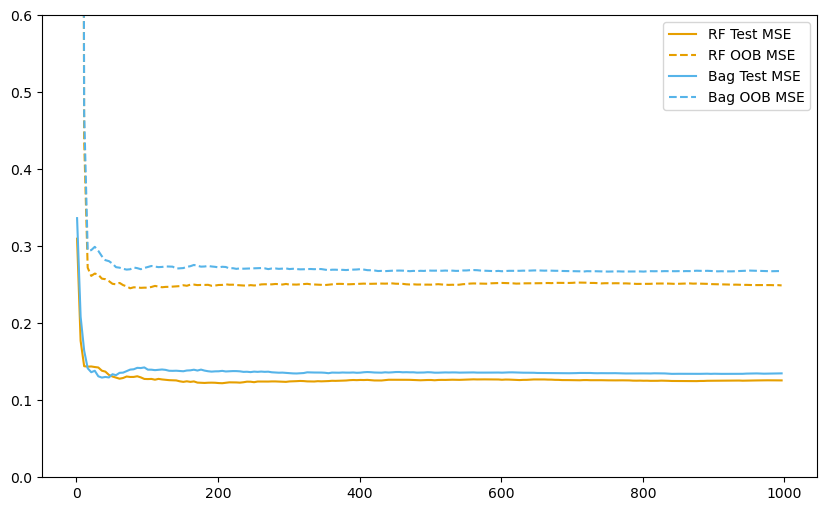

In [44]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(bag_vec,rf_test,"-",color = oi_colors[0],label = "RF Test MSE")
ax.plot(bag_vec,rf_oob,"--",color = oi_colors[0],label = "RF OOB MSE")

ax.plot(bag_vec,bag_test,"-",color = oi_colors[1],label = "Bag Test MSE")
ax.plot(bag_vec,bag_oob,"--",color = oi_colors[1],label = "Bag OOB MSE")

ax.set_ylim(0.0,.6)
ax.legend()

In [45]:
RF_Hitters = RF(max_features = 3,n_estimators=500, random_state =1)

RF_Hitters.fit(X_train,y_train)
feature_imp = pd.DataFrame(
    {'importance':RF_Hitters.feature_importances_},
    index = feature_names
).sort_values(by="importance",ascending=False)



In [46]:
feature_imp.head()

,importance
num__CAtBat,0.157940
num__CHits,0.133453
num__CRuns,0.124125
num__CRBI,0.113214
num__CWalks,0.089591


<positron-console-cell-50>:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


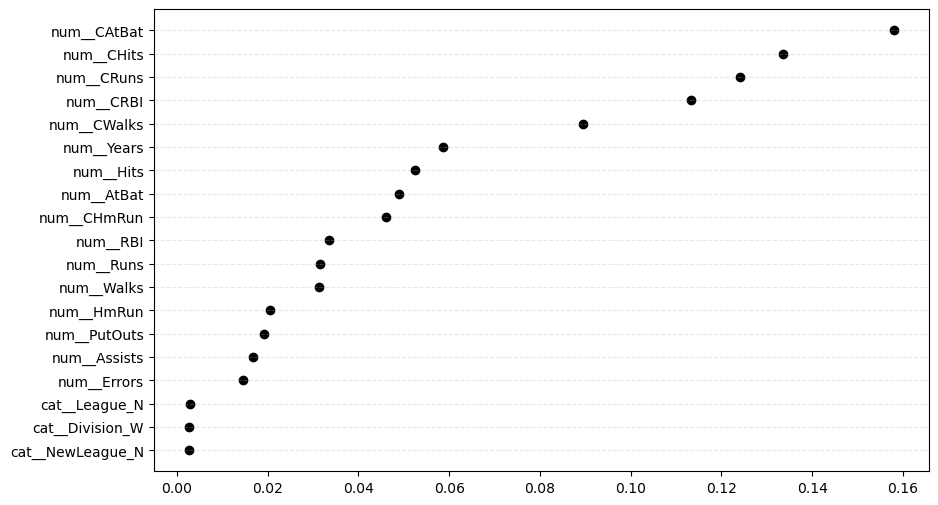

In [50]:
fig, ax =plt.subplots(figsize=(10,6))

ax.scatter(feature_imp,range(p),color='k')

ax.invert_yaxis()
ax.set_yticklabels(feature_imp.index)
ax.set_yticks(range(p))
ax.grid(axis='y',linestyle="--",alpha=0.3)



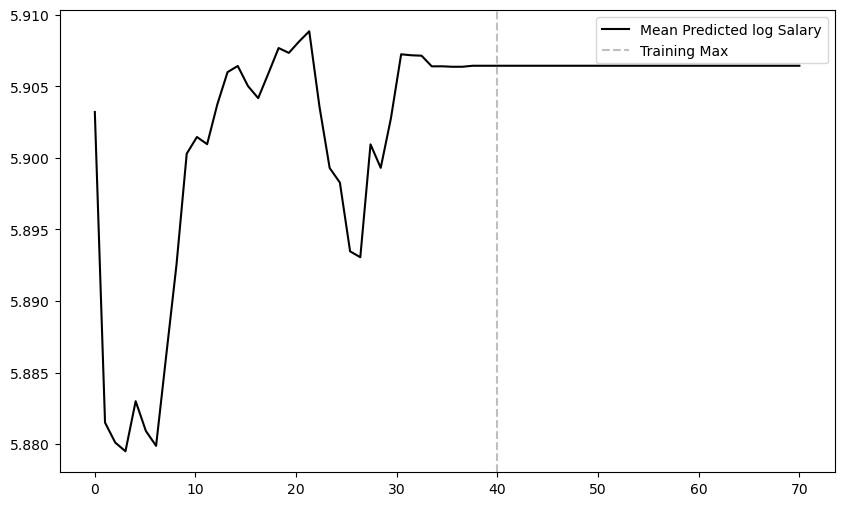

In [54]:
HMRun_idx = feature_names.index("num__HmRun")

grid_values = np.linspace(0,70,70)

pdp_values = []

for val in grid_values:
    X_temp = X_train.copy()
    X_temp[:,HMRun_idx] = val

    pdp_values.append(RF_Hitters.predict(X_temp).mean())

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(grid_values,pdp_values,color="k",label = "Mean Predicted log Salary")

ax.axvline(X_train[:,HMRun_idx].max(),color="gray",linestyle = "--",alpha= 0.5,label = "Training Max")

ax.legend()


